# Gradient Monte Carlo with State Aggregation

**Reproduces S&B Example 9.1 / Figure 9.1** (§9.3, p.203).

The **1000-state random walk**: a prediction (policy-evaluation) task. The agent
starts in the center and, from each state, jumps uniformly to one of the 100
neighbors on each side; falling off an edge terminates with reward −1 (left) or
+1 (right). We approximate the value function with **state aggregation** (1000
states grouped into 10 bins of 100), learned by **gradient Monte Carlo**, and
compare the resulting step-function `v̂` to the true `v_π`.

The pieces line up as: **environment** → **policy** → **ground truth** (exact
`v_π`, distribution `μ`) → **representation** (feature map) → **model** (linear
approximator) → **learner** (gradient MC).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from rl.envs.random_walk import RandomWalk
from rl.dynamic_programming.policy_evaluation import policy_value, on_policy_distribution
from rl.features.state_aggregation import StateAggregation
from rl.approximators.linear import LinearValue
from rl.prediction_approx.gradient_mc import gradient_mc

from random_walk_policy import uniform_jump_policy, policy_sampler
from random_walk_plots import plot_figure_9_1

## 1. Environment and policy

The walk is a *fixed* policy on a deterministic chain (action = next state), so
`pi` is the `±100` uniform-jump distribution and the chain is the non-terminal
states.

In [2]:
env = RandomWalk(n_states=1000)                 # states 1..1000; terminals 0 and 1001; gamma = 1
pi = uniform_jump_policy(env, max_step=100)     # +/-100 uniform walk (Example 9.1)
chain = [s for s in range(env.n_states) if s not in env.terminal_states()]
print(f'states (incl. terminals): {env.n_states}, start: {env.START}, chain: {len(chain)}')

states (incl. terminals): 1002, start: 500, chain: 1000


## 2. Ground truth (exact, from the known model)

Since the model is known, we solve for the exact `v_π` and the on-policy
distribution `μ` directly (no learning). These are what we compare the learned
approximation against.

In [3]:
v_true = policy_value(env, pi)            # exact v_pi  (= (I - gamma P_pi)^-1 r_pi)
mu = on_policy_distribution(env, pi)      # on-policy state distribution
print(f'v_true: v[1]={v_true[1]:.3f}, v[500]={v_true[500]:.3f}, v[1000]={v_true[1000]:.3f}')

v_true: v[1]=-0.922, v[500]=-0.001, v[1000]=0.922


## 3. Approximate by gradient Monte Carlo + state aggregation

- **Representation:** `StateAggregation` — 10 groups of 100 states; `x(s)` is
  one-hot over the group, so `v̂(s) = w[group(s)]` (a step function).
- **Model:** `LinearValue` — holds the 10 weights `w`, predicts `v̂ = w·x(s)`,
  reports its gradient (`= x(s)`); it does **not** update itself.
- **Learner:** `gradient_mc` — owns the update `w ← w + α(G_t − v̂)·x` toward
  the full return.

Book settings: 10 groups, `α = 2e-5`, `100,000` episodes (takes ~1 min).

In [4]:
agg = StateAggregation(chain, n_groups=10)
value_fn = LinearValue(agg)

rng = np.random.default_rng(seed=0)
gradient_mc(env, policy_sampler(pi), value_fn, rng, n_episodes=100_000, alpha=2e-5)

v_hat = value_fn.all_values(env.n_states)
print('learned group values:', np.round(value_fn.w, 3))

learned group values: [-0.83  -0.66  -0.466 -0.281 -0.092  0.09   0.273  0.468  0.645  0.818]


## 4. Figure 9.1

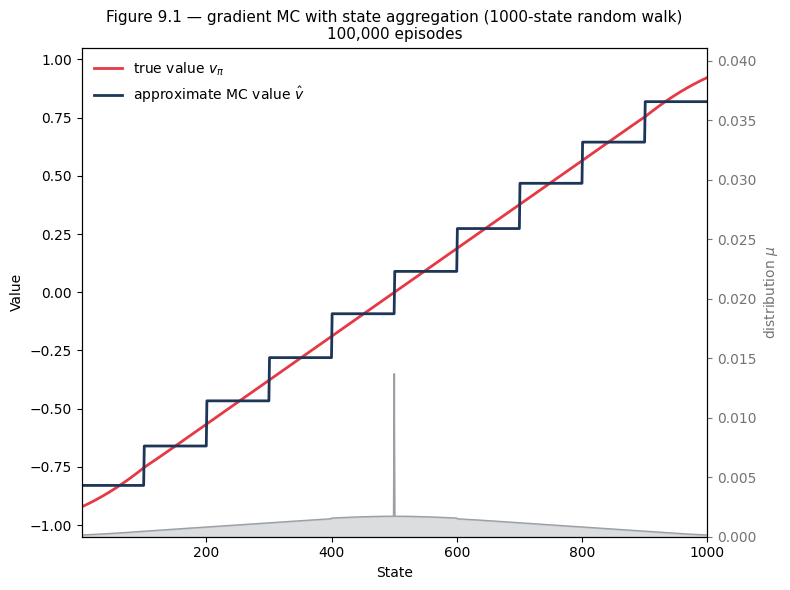

In [5]:
fig = plot_figure_9_1(chain, v_hat[chain], v_true[chain], mu[chain], n_episodes=100_000)
plt.show()

**Reading it.** `v̂` is a 10-step staircase: aggregation forces all 100 states in
a group to share one value, so it can track the true `v_π` only coarsely — it
cannot represent the within-group slope. Note the ends: the leftmost / rightmost
steps don't reach −1 / +1, because each is the average over its group and is
pulled in by `μ` (states are visited more toward the center). The grey `μ` curve
(right axis) is that on-policy visitation distribution, which is also the
weighting in the value error the method actually minimizes.